# Архитектура агента с инструментами-actuators

> Внимание! Материал ноутбука подходит для работы в Google Colaboratory. Мы не можем гарантировать стабильную работу кода на личных устройствах и на других системах виртуализации.

## Введение

### Постановка проблемы

На занятии мы познакомимся с **tool calling** — механизмом, который позволяет языковой модели запросить выполнение функции из нашего приложения. В документации также встречается название **Function Calling**. Здесь оба термина обозначают один протокол: модель возвращает структурированное предложение, а приложение решает, можно ли его выполнить.

Сам по себе GigaChat не знает текущий статус платежа во внутренней системе и не может самостоятельно создать обращение в поддержку. Приложение передаёт модели описания доступных Python-функций: имена, назначение и аргументы. В ответ GigaChat может вернуть не догадку в свободной форме, а предложение вида `get_payment(payment_id="P-77")`.

Tool calling нужен, чтобы:

- получать актуальные данные из базы, API или внутренней службы;
- предлагать действия во внешней системе: создать обращение, отправить сообщение или запустить операцию.

Механизм не даёт модели прямого доступа к Python. В нашем примере обмен выглядит так:

1. Пользователь просит проверить двойное списание по платежу `P-77`.
2. GigaChat либо отвечает текстом, либо предлагает вызвать функцию.
3. Приложение проверяет имя функции, аргументы и право на действие.
4. Только после проверки приложение вызывает обычную Python-функцию.
5. Результат функции возвращается модели, чтобы она могла выбрать следующий шаг или сформулировать ответ.

Ключевая мысль: **GigaChat предлагает функцию, но не исполняет её сам**. Ответ модели — входные данные для нашей программы.

Пока достаточно двух определений:

- **инструмент (tool)** — Python-функция, описание которой передано модели;
- **вызов инструмента (tool call)** — предложение модели с именем функции и аргументами.

Остальные термины вводятся непосредственно перед кодом, где они понадобятся.

### Цели занятия

После занятия вы сможете создать клиент `GigaChat-2-Max`, проверить подключение простым запросом, передать модели описания Python-функций, безопасно выполнить предложенный вызов и ограничить цикл «модель → функция → модель».

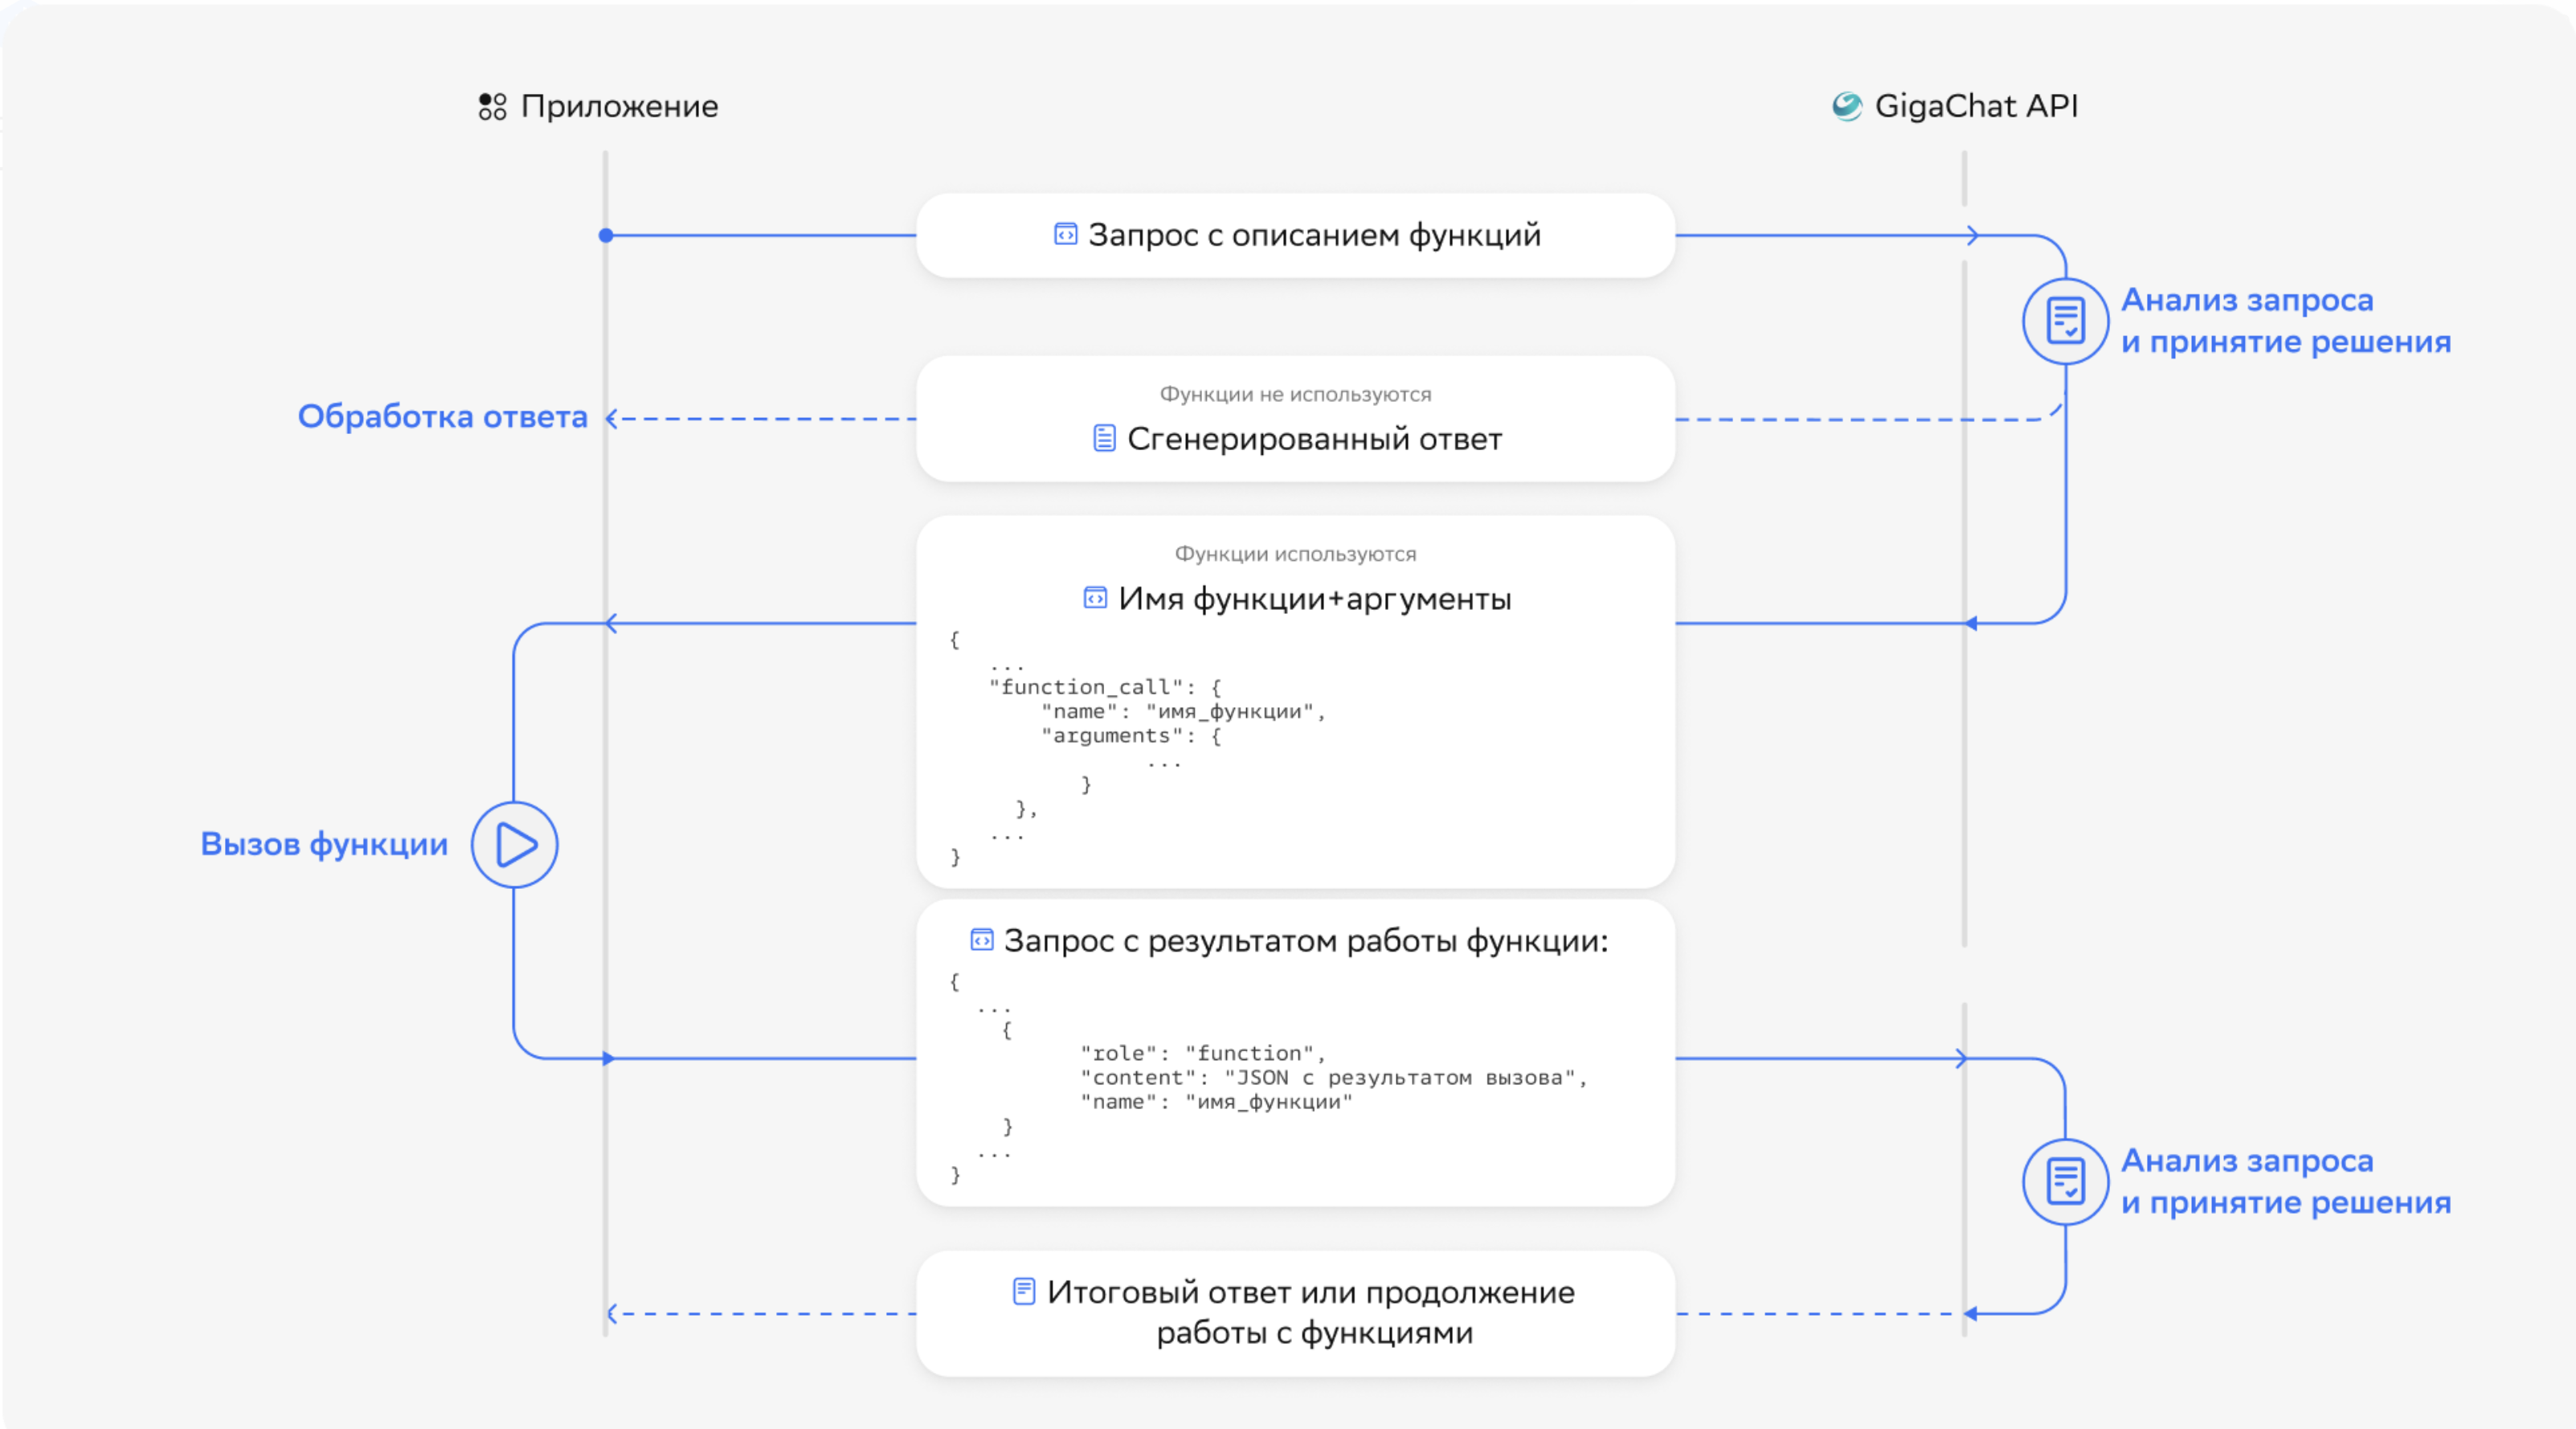

*Рисунок 1. Схема Function Calling: как приложение и GigaChat обмениваются вызовами функций*

### Основные понятия занятия

Эта таблица нужна как опора перед первым запуском кода. Названия полей API оставлены на английском, потому что именно такими они встречаются в сообщениях LangChain.

| Понятие | Что означает | Для чего нужно |
|---|---|---|
| AI-агент | LLM вместе с инструментами, состоянием и правилом остановки, которыми управляет приложение. | Выполнять несколько проверяемых шагов, а не ограничиваться одним текстовым ответом модели. |
| LangChain | Python-библиотека, которая описывает инструменты и форматы сообщений между моделью и приложением. | Не собирать протокол вызова функций и `ToolMessage` вручную на уровне HTTP. |
| Tool calling (`Function Calling`) | Протокол, в котором модель предлагает имя функции и структурированные аргументы. | Связать ответ модели с данными и действиями приложения. |
| Инструмент (`tool`) | Python-функция вместе с описанием и схемой аргументов, показанными модели. | Дать модели понятный список доступных возможностей. |
| Схема инструмента | Описание имён, типов и обязательности аргументов. | Проверить вызов до выполнения Python-функции. |
| Вызов инструмента (`tool call`) | Предложение модели вызвать конкретный инструмент с аргументами. | Передать приложению не свободный текст, а проверяемую команду. |
| `tool_call_id` | Идентификатор запроса инструмента, который формирует поставщик модели; приложение переносит его в ответ `ToolMessage`. | Однозначно связать результат с исходным вызовом, особенно если вызовов несколько. |
| Среда выполнения (`runtime`) | Код приложения вокруг модели: проверки, вызов Python-функции и возврат результата. | Сохранить контроль над тем, что действительно будет выполнено. |
| Проверка допуска (`gate`) | Набор правил для имени инструмента, аргументов и необходимости подтверждения. | Отклонить запрещённый или некорректный вызов до побочного эффекта. |
| `ToolMessage` | Сообщение с результатом инструмента и тем же `tool_call_id`. | Вернуть модели наблюдение в формате, который она может связать со своим запросом. |
| Состояние | Данные, накопленные между шагами: сообщения, счётчики и результаты. | Продолжить цикл без потери уже полученных фактов. |
| Побочный эффект | Изменение вне программы, например создание обращения или отправка сообщения. | Отделить безопасное чтение от действий, которым может требоваться подтверждение. |
| Ограниченный цикл (`bounded loop`) | Цикл «модель → инструмент → модель» с предельным числом шагов. | Гарантированно остановить агента при зацикливании или неудачных ответах. |
| Бюджет шагов и причина остановки | Допустимое число итераций и явная метка того, почему цикл завершён. | Контролировать стоимость и отличать нормальный ответ от исчерпания предела. |

##Установка зависимостей
Установим необходимые библиотеки.

In [ ]:
# %pip install -q "deepagents>=0.5,<0.6" "gigachat>=0.2,<0.3" "langchain>=1.3,<2" "langchain-gigachat>=0.5,<0.6" "langgraph>=1.2,<2" "python-dotenv>=1,<2"

#  Добавьте GIGACHAT_CREDENTIALS в панель Colab «Секреты» и разрешите
#  notebook доступ к нему. Затем раскомментируйте следующие три строки.

import os
from dotenv import load_dotenv
load_dotenv()
# os.environ["GIGACHAT_CREDENTIALS"] = userdata.get("GIGACHAT_CREDENTIALS")

from pprint import pprint

: 

## 1. Создаём GigaChat-2-Max и проверяем подключение

Локально найдём `.env`; в Google Colab используем `GIGACHAT_CREDENTIALS`, уже прочитанный из Secrets в первой ячейке. Затем создадим обычный экземпляр `GigaChat` без инструментов. Модель явно задана как `GigaChat-2-Max`; данные авторизации код не печатает.

Затем отправим один короткий запрос. Непустой ответ означает, что авторизация, сертификаты, адрес API и доступ к модели настроены правильно. Этот же экземпляр `gigachat` дальше получит описания Python-функций.

In [ ]:
import os
from pathlib import Path

from dotenv import find_dotenv, load_dotenv
from langchain_gigachat.chat_models import GigaChat


ENV_FILE = find_dotenv(usecwd=True)
if ENV_FILE:
    load_dotenv(ENV_FILE)
if not os.getenv("GIGACHAT_CREDENTIALS"):
    raise RuntimeError(
        "задайте GIGACHAT_CREDENTIALS в корневом .env или в Colab Secrets"
    )
ENV_SOURCE = Path(ENV_FILE).name if ENV_FILE else "Colab Secrets / environment"

GIGACHAT_MODEL = "GigaChat-2-Max"
gigachat_kwargs = {
    "credentials": os.environ["GIGACHAT_CREDENTIALS"],
    "scope": os.getenv("GIGACHAT_SCOPE", "GIGACHAT_API_B2B"),
    "model": GIGACHAT_MODEL,
    "verify_ssl_certs": False
}
if os.getenv("GIGACHAT_CA_BUNDLE_FILE"):
    gigachat_kwargs["ca_bundle_file"] = os.environ["GIGACHAT_CA_BUNDLE_FILE"]
if os.getenv("GIGACHAT_BASE_URL"):
    gigachat_kwargs["base_url"] = os.environ["GIGACHAT_BASE_URL"]

gigachat = GigaChat(**gigachat_kwargs)
connection_check_response = gigachat.invoke(
    "Ответь одной короткой строкой: подключение к GigaChat-2-Max работает."
)

assert isinstance(connection_check_response.content, str)
assert connection_check_response.content.strip()

from pprint import pprint
pprint({
    "проверка_подключения": {
        "источник": "gigachat_online",
        "источник_настроек": ENV_SOURCE,
        "модель": GIGACHAT_MODEL,
        "ответ": connection_check_response.content,
        "response_id": connection_check_response.id,
        "использование": connection_check_response.usage_metadata,
    }
})

: 

Непустой ответ подтверждает всю цепочку подключения; вывод показывает источник настроек, модель и служебные метаданные без секретов.

## Что делаем дальше

Подключение уже проверено. Теперь будем наращивать один и тот же пример `P-77`:

1. Создадим три обычные Python-функции.
2. Передадим GigaChat их имена, описания и аргументы.
3. Посмотрим, какую функцию и с какими аргументами предложила модель.
4. Проверим предложение, вызовем функцию в приложении и вернём результат GigaChat.
5. Соберём ограниченный цикл из нескольких таких шагов.

## Где нужен GigaChat, а где достаточно обычного кода

| Ситуация | Подход | Почему |
|---|---|---|
| Показать инструкцию по смене пароля | обычная Python-функция | вопрос и ответ известны заранее |
| Провести продавца через регистрацию | фиксированная последовательность шагов | порядок не меняется: реквизиты → проверка → активация |
| Найти причину деградации API | повторяющийся обмен с GigaChat | новые метрики определяют, какую функцию вызвать дальше |
| Создать обращение после расследования | GigaChat предлагает, приложение проверяет | чтение данных безопасно, а реальное действие требует подтверждения |

Повторяющийся обмен с моделью нужен не для любого вопроса, а когда следующий шаг зависит от новых данных. Ниже мы соберём такой процесс постепенно, начиная с одного вызова функции.

## 2. GigaChat и три инструмента

Вместо настоящей базы данных используем небольшой набор аккаунтов и платежей в памяти. В нём есть обычный платёж, подтверждённый дубликат, отклонённый платёж, аккаунт на проверке риска и неизвестный идентификатор.

GigaChat сможет выбирать между тремя Python-функциями:

- `get_account` читает данные аккаунта;
- `get_payment` читает данные платежа;
- `create_support_ticket` создаёт обращение в системе поддержки.

Первые две функции ничего не изменяют — это **инструменты чтения** (`read-only tools`). Третья функция имеет побочный эффект: после неё появляется новый объект во внешней системе. Такие инструменты называют **actuators**, то есть инструментами-действиями.

`Actuator` — не специальный класс GigaChat или LangChain, а архитектурный термин. Так называют функцию, которая меняет внешний мир: создаёт обращение, отправляет сообщение, проводит платёж или запускает развёртывание. Ошибка чтения даст неверный ответ, а ошибка actuator может изменить реальную систему, поэтому перед таким вызовом нужны дополнительные проверки.

Для создания обращения используется `idempotency_key` — уникальный ключ бизнес-операции. Если один и тот же запрос случайно повторится с тем же ключом, приложение вернёт уже созданное обращение, а не создаст второе. Это и есть **идемпотентность**: повтор операции с тем же ключом не создаёт дополнительного внешнего изменения.

In [3]:
import json
from typing import NamedTuple

from langchain.tools import tool
from langchain_core.messages import HumanMessage, ToolMessage


ACCOUNTS = {
    "A-1": {
        "plan": "business", "region": "eu", "status": "active",
        "risk_hold": False,
    },
    "B-2": {
        "plan": "starter", "region": "ru", "status": "review",
        "risk_hold": True,
    },
}

PAYMENTS = {
    "P-76": {
        "account_id": "A-1", "status": "captured", "amount": 1490,
        "currency": "RUB", "duplicate_of": None,
    },
    "P-77": {
        "account_id": "A-1", "status": "captured", "amount": 1490,
        "currency": "RUB", "duplicate_of": "P-76",
    },
    "P-78": {
        "account_id": "A-1", "status": "declined", "amount": 3200,
        "currency": "RUB", "duplicate_of": None,
    },
}


@tool
def get_account(account_id: str) -> dict:
    """Получить проверенные тариф, регион, статус и флаги риска аккаунта."""
    account = ACCOUNTS.get(account_id)
    if account is None:
        return {"found": False, "account_id": account_id}
    return {"found": True, "account_id": account_id, **account}


@tool
def get_payment(payment_id: str) -> dict:
    """Получить статус, сумму и связь платежа с исходной операцией."""
    payment = PAYMENTS.get(payment_id)
    if payment is None:
        return {"found": False, "payment_id": payment_id}
    return {"found": True, "payment_id": payment_id, **payment}


ticket_effects: dict[str, dict] = {}


@tool
def create_support_ticket(summary: str, idempotency_key: str) -> dict:
    """Создать обращение после проверки фактов и разрешения среды выполнения."""
    if idempotency_key in ticket_effects:
        return {**ticket_effects[idempotency_key], "replayed": True}
    ticket = {
        "ticket_id": f"T-{100 + len(ticket_effects)}",
        "summary": summary,
        "status": "open",
    }
    ticket_effects[idempotency_key] = ticket
    return {**ticket, "replayed": False}


TOOLS = {
    current_tool.name: current_tool
    for current_tool in (get_account, get_payment, create_support_ticket)
}
READ_ONLY_TOOLS = {"get_account", "get_payment"}
ACTUATORS = {"create_support_ticket"}


def build_gigachat_with_tools(*, tool_choice: str = "auto"):
    """Передаёт GigaChat все три схемы и выбранный режим Function Calling."""
    if "gigachat" not in globals():
        raise RuntimeError("сначала выполните проверку подключения к GigaChat-2-Max")
    return gigachat.bind_tools(list(TOOLS.values()), tool_choice=tool_choice)


assert set(TOOLS) == READ_ONLY_TOOLS | ACTUATORS
assert callable(build_gigachat_with_tools)

pprint({
    "реестр_инструментов": [
        {
            "имя": name,
            "вид": "actuator" if name in ACTUATORS else "чтение",
            "схема": current_tool.args_schema.model_json_schema()["properties"],
        }
        for name, current_tool in TOOLS.items()
    ],
    "подключение": "GigaChat.bind_tools",
    "примеры_результатов": {
        "обычный_платёж": get_payment.invoke({"payment_id": "P-76"}),
        "дубликат": get_payment.invoke({"payment_id": "P-77"}),
        "отклонённый_платёж": get_payment.invoke({"payment_id": "P-78"}),
        "неизвестный_платёж": get_payment.invoke({"payment_id": "P-404"}),
        "аккаунт_на_проверке": get_account.invoke({"account_id": "B-2"}),
        "неизвестный_аккаунт": get_account.invoke({"account_id": "A-404"}),
    },
})

{'подключение': 'GigaChat.bind_tools',
 'примеры_результатов': {'аккаунт_на_проверке': {'account_id': 'B-2',
                                                 'found': True,
                                                 'plan': 'starter',
                                                 'region': 'ru',
                                                 'risk_hold': True,
                                                 'status': 'review'},
                         'дубликат': {'account_id': 'A-1',
                                      'amount': 1490,
                                      'currency': 'RUB',
                                      'duplicate_of': 'P-76',
                                      'found': True,
                                      'payment_id': 'P-77',
                                      'status': 'captured'},
                         'неизвестный_аккаунт': {'account_id': 'A-404',
                                                 'found': False},
            

Один инструмент чтения возвращает разные проверенные результаты для обычного, дублированного, отклонённого и неизвестного платежа; GigaChat получает схему функции, а не заранее заданный ответ.

## 3. Механизм Function Calling

GigaChat не вызывает функцию сам. В ответе модели появляется список `tool_calls`. Каждый элемент содержит:

- `name` — имя предложенной функции;
- `args` — словарь её аргументов;
- `id` — уникальный идентификатор предложения.

Приложение находит функцию по `name` и вызывает её обычным Python-кодом. Затем оно создаёт `ToolMessage` — сообщение с результатом функции для GigaChat. Поле `tool_call_id` равно исходному `id`, чтобы модель понимала, к какому вызову относится результат.

В первой демонстрации используется `tool_choice="get_account"`. Это требование приложения вернуть вызов именно `get_account`, а не самостоятельный выбор модели. Так мы гарантированно увидим формат Function Calling. В итоговом цикле будет `tool_choice="auto"`: там GigaChat сам решает, нужен ли инструмент и какой именно.

Пока мы вручную проверим ожидаемое имя и аргументы. Универсальную проверку для всех трёх функций соберём в следующем разделе.

In [4]:
# Передаём GigaChat описания функций. Имя get_account выбрано принудительно,
# чтобы первый разбор протокола был предсказуемым.
function_call_response = build_gigachat_with_tools(tool_choice="get_account").invoke(
    "У клиента A-1 двойное списание P-77. Запроси проверенные данные аккаунта."
)

# На этом этапе Python-функция ещё не вызвана: модель только вернула предложение.
if len(function_call_response.tool_calls) != 1:
    raise RuntimeError("GigaChat должен вернуть один вызов get_account")
selected_call = function_call_response.tool_calls[0]

# Принудительный выбор фиксирует имя, но аргументы всё равно пришли от модели.
# До вызова функции вручную проверяем ожидаемые имя, аргументы и идентификатор.
if (
    selected_call.get("name") != "get_account"
    or selected_call.get("args") != {"account_id": "A-1"}
    or not str(selected_call.get("id", "")).strip()
):
    raise RuntimeError(f"неожиданное предложение GigaChat: {selected_call}")

# Только теперь приложение находит функцию в своём реестре и вызывает её.
selected_function = TOOLS[selected_call["name"]]
python_result = selected_function.invoke(selected_call["args"])

# ToolMessage возвращает результат модели. tool_call_id связывает его с
# конкретным предложением, даже если в истории несколько вызовов функций.
tool_message = ToolMessage(
    content=json.dumps({"status": "ok", "data": python_result}, ensure_ascii=False),
    tool_call_id=selected_call["id"],
    name=selected_call["name"],
)

assert selected_call["id"] == tool_message.tool_call_id
assert json.loads(tool_message.content)["data"]["account_id"] == "A-1"

pprint({
    "механика_function_calling": {
        "ответ_модели": {
            "текст": function_call_response.content,
            "tool_calls": function_call_response.tool_calls,
        },
        "выбранная_python_функция": selected_function.name,
        "результат_python": python_result,
        "tool_message": {
            "name": tool_message.name,
            "tool_call_id": tool_message.tool_call_id,
            "content": json.loads(tool_message.content),
        },
    }
})

{'механика_function_calling': {'tool_message': {'content': {'data': {'account_id': 'A-1',
                                                                     'found': True,
                                                                     'plan': 'business',
                                                                     'region': 'eu',
                                                                     'risk_hold': False,
                                                                     'status': 'active'},
                                                            'status': 'ok'},
                                                'name': 'get_account',
                                                'tool_call_id': 'bd9d651f-b616-44ea-b8e2-a639faac72e1'},
                               'выбранная_python_функция': 'get_account',
                               'ответ_модели': {'tool_calls': [{'args': {'account_id': 'A-1'},
                                                   

Function Calling — протокол, а не удалённое исполнение: GigaChat формирует предложение, приложение проверяет его и вызывает Python-функцию, а `ToolMessage` связывает результат с исходным предложением.

## 4. Задание: проверка перед вызовом функции

Перед вызовом Python-функции поставим защитную проверку. В архитектуре агента её часто называют **runtime gate**, или проверкой среды выполнения. Это обычная функция приложения, которая отвечает на четыре вопроса:

1. Есть ли имя в списке разрешённых инструментов (`allowlist`)?
2. Переданы ли ровно ожидаемые поля, без пропущенных и лишних (`closed schema`)?
3. Совпадают ли типы значений, например `account_id` — строка?
4. Разрешена ли выбранная функция на текущем этапе процесса?

### Что здесь означает `state`

`state` — текущее **состояние процесса**, которое хранит Python-приложение. Оно не берётся из текста GigaChat и не меняется по желанию модели.

В первом занятии достаточно двух состояний:

- `расследование` — агент собирает факты; разрешены только инструменты чтения;
- `выполнение` — приложение готово выполнить заранее сформированное действие.

Одного `state="выполнение"` недостаточно: actuator разрешается только при `approved=True`. Состояние отвечает на вопрос «на каком этапе находится процесс», а `approved` — «подтвердил ли человек это действие».

В этом занятии готовое состояние передаётся в `gate_tool_call()` аргументом. Правила переходов и конечный автомат состояний (FSM) мы построим во втором занятии.

Проверка возвращает понятный статус:

- `ok` — функцию можно вызвать;
- `validation_error` — модель передала неправильные аргументы и может исправить вызов;
- `policy_denied` — функция или состояние запрещены;
- `approval_required` — допустимое действие ждёт подтверждения человека.

In [5]:
class GateResult(NamedTuple):
    status: str
    reason: str


TOOL_FIELDS = {
    "get_account": {"account_id": str},
    "get_payment": {"payment_id": str},
    "create_support_ticket": {"summary": str, "idempotency_key": str},
}
PROCESS_STATES = {"расследование", "выполнение"}


def proposed_call(name: str, args: dict, call_id: str) -> dict:
    """Создаёт учебное предложение в формате LangChain tool call."""
    return {"name": name, "args": args, "id": call_id, "type": "tool_call"}


ticket_args = {"summary": "двойное списание P-77", "idempotency_key": "case-7:v1"}
gate_cases = {
    "чтение_разрешено": (
        proposed_call("get_account", {"account_id": "A-1"}, "c-1"),
        "расследование", False,
    ),
    "чтение_не_в_той_фазе": (
        proposed_call("get_account", {"account_id": "A-1"}, "c-1b"),
        "выполнение", False,
    ),
    "неверные_аргументы": (
        proposed_call("get_account", {"account": "A-1"}, "c-2"),
        "расследование", False,
    ),
    "пустой_id": (
        proposed_call("get_account", {"account_id": "A-1"}, " "),
        "расследование", False,
    ),
    "неизвестное_состояние": (
        proposed_call("get_account", {"account_id": "A-1"}, "c-2b"),
        "закрыто", False,
    ),
    "неизвестная_функция": (
        proposed_call("shell", {"command": "whoami"}, "c-3"),
        "расследование", False,
    ),
    "действие_не_в_той_фазе": (
        proposed_call("create_support_ticket", ticket_args, "c-4"),
        "расследование", True,
    ),
    "ожидает_подтверждения": (
        proposed_call("create_support_ticket", ticket_args, "c-5"),
        "выполнение", False,
    ),
    "действие_разрешено": (
        proposed_call("create_support_ticket", ticket_args, "c-6"),
        "выполнение", True,
    ),
}

pprint({
    "контракт_проверки": {
        "разрешённые_инструменты": sorted(TOOLS),
        "схемы": {name: list(fields) for name, fields in TOOL_FIELDS.items()},
        "состояния": {
            "расследование": "только инструменты чтения",
            "выполнение": "actuator только вместе с approved=True",
        },
        "завершают_цикл": ["policy_denied", "approval_required"],
        "можно_исправить": ["validation_error"],
    }
})

{'контракт_проверки': {'завершают_цикл': ['policy_denied', 'approval_required'],
                       'можно_исправить': ['validation_error'],
                       'разрешённые_инструменты': ['create_support_ticket',
                                                   'get_account',
                                                   'get_payment'],
                       'состояния': {'выполнение': 'actuator только вместе с '
                                                   'approved=True',
                                     'расследование': 'только инструменты '
                                                      'чтения'},
                       'схемы': {'create_support_ticket': ['summary',
                                                           'idempotency_key'],
                                 'get_account': ['account_id'],
                                 'get_payment': ['payment_id']}}}


До обращения к модели среда выполнения уже знает разрешённые инструменты, точные схемы и два состояния процесса; инструкция для модели не заменяет эти правила.

In [6]:
def gate_tool_call(call: dict, *, state: str, approved: bool) -> GateResult:
    """Проверяет предложенный GigaChat tool call до выполнения функции."""
    # Пустой provider id нельзя корректно связать с ToolMessage. Такой ответ
    # завершает цикл: просить модель исправить идентификатор небезопасно.
    if (
        not isinstance(call, dict)
        or call.get("type") != "tool_call"
        or not isinstance(call.get("id"), str)
        or not call["id"].strip()
    ):
        return GateResult("policy_denied", "нужен непустой provider call id")

    # Имя и аргументы пришли от модели и пока считаются недоверенными данными.
    name, args = call.get("name"), call.get("args")
    if name not in TOOLS:
        return GateResult("policy_denied", "функция отсутствует в allowlist")

    # Точная схема запрещает пропущенные и лишние поля.
    schema = TOOL_FIELDS[name]
    if not isinstance(args, dict) or set(args) != set(schema):
        return GateResult("validation_error", "аргументы не совпадают со схемой")
    if any(type(args[field]) is not expected for field, expected in schema.items()):
        return GateResult("validation_error", "неверный тип аргумента")

    # Состояние и approved задаёт приложение, но gate всё равно не доверяет
    # повреждённым значениям и не расширяет из-за них полномочия.
    if state not in PROCESS_STATES or not isinstance(approved, bool):
        return GateResult("policy_denied", "неизвестное состояние процесса")
    if name in READ_ONLY_TOOLS and state != "расследование":
        return GateResult("policy_denied", "чтение разрешено только при расследовании")
    if name in ACTUATORS and state != "выполнение":
        return GateResult("policy_denied", "actuator разрешён только при выполнении")
    if name in ACTUATORS and not approved:
        return GateResult("approval_required", "нужно подтверждение человека")

    return GateResult("ok", "вызов разрешён")

gate_results = {
    name: gate_tool_call(call, state=state, approved=approved)
    for name, (call, state, approved) in gate_cases.items()
}
assert {name: result.status for name, result in gate_results.items()} == {
    "чтение_разрешено": "ok",
    "чтение_не_в_той_фазе": "policy_denied",
    "неверные_аргументы": "validation_error",
    "пустой_id": "policy_denied",
    "неизвестное_состояние": "policy_denied",
    "неизвестная_функция": "policy_denied",
    "действие_не_в_той_фазе": "policy_denied",
    "ожидает_подтверждения": "approval_required",
    "действие_разрешено": "ok",
}

pprint({
    "результаты_проверки": {
        name: result._asdict() for name, result in gate_results.items()
    }
})

{'результаты_проверки': {'действие_не_в_той_фазе': {'reason': 'actuator '
                                                              'разрешён только '
                                                              'при выполнении',
                                                    'status': 'policy_denied'},
                         'действие_разрешено': {'reason': 'вызов разрешён',
                                                'status': 'ok'},
                         'неверные_аргументы': {'reason': 'аргументы не '
                                                          'совпадают со схемой',
                                                'status': 'validation_error'},
                         'неизвестная_функция': {'reason': 'функция '
                                                           'отсутствует в '
                                                           'allowlist',
                                                 'status': 'policy_denied'},
               

Проверка разрешает чтение только при расследовании, отделяет исправимые аргументы от запрета, завершающего цикл, и требует подтверждение для actuator в состоянии выполнения.

## 5. Задание: безопасный вызов и результат для GigaChat

Вызывайте Python-функцию только после результата `status="ok"`. Для каждого предложения сформируйте `ToolMessage` с тем же `tool_call_id`. Исправимый `validation_error` можно вернуть модели; при `policy_denied` и `approval_required` наш цикл завершится без нового обращения к модели.

In [7]:
def execute_tool_call(call: dict, *, state: str, approved: bool) -> ToolMessage:
    """Проверяет предложение, при разрешении вызывает функцию и возвращает результат."""
    gate = gate_tool_call(call, state=state, approved=approved)
    payload: dict = {"status": gate.status, "reason": gate.reason}

    # Только статус ok пересекает границу между предложением и исполнением.
    if gate.status == "ok":
        payload["data"] = TOOLS[call["name"]].invoke(call["args"])

    # Для корректного provider call всегда сохраняем исходные id и name.
    return ToolMessage(
        content=json.dumps(payload, ensure_ascii=False),
        tool_call_id=call.get("id", "missing-call-id"),
        name=call.get("name", "unknown"),
    )

ticket_effects.clear()
read_observation = execute_tool_call(
    gate_cases["чтение_разрешено"][0], state="расследование", approved=False,
)
blocked_observation = execute_tool_call(
    gate_cases["ожидает_подтверждения"][0], state="выполнение", approved=False,
)
approved_call = gate_cases["действие_разрешено"][0]
approved_observation = execute_tool_call(
    approved_call, state="выполнение", approved=True,
)
replayed_observation = execute_tool_call(
    approved_call, state="выполнение", approved=True,
)

observation_payloads = {
    "чтение": json.loads(read_observation.content),
    "заблокировано": json.loads(blocked_observation.content),
    "выполнено": json.loads(approved_observation.content),
    "повтор": json.loads(replayed_observation.content),
}
assert read_observation.tool_call_id == "c-1"
assert observation_payloads["заблокировано"]["status"] == "approval_required"
assert "data" not in observation_payloads["заблокировано"]
assert observation_payloads["выполнено"]["data"]["replayed"] is False
assert observation_payloads["повтор"]["data"]["replayed"] is True
assert len(ticket_effects) == 1

pprint({
    "наблюдения_инструментов": {
        name: {
            "tool_call_id": message.tool_call_id,
            "содержимое": observation_payloads[name],
        }
        for name, message in {
            "чтение": read_observation,
            "заблокировано": blocked_observation,
            "выполнено": approved_observation,
            "повтор": replayed_observation,
        }.items()
    },
    "созданные_обращения": ticket_effects,
})

{'наблюдения_инструментов': {'выполнено': {'tool_call_id': 'c-6',
                                           'содержимое': {'data': {'replayed': False,
                                                                   'status': 'open',
                                                                   'summary': 'двойное '
                                                                              'списание '
                                                                              'P-77',
                                                                   'ticket_id': 'T-100'},
                                                          'reason': 'вызов '
                                                                    'разрешён',
                                                          'status': 'ok'}},
                             'заблокировано': {'tool_call_id': 'c-5',
                                               'содержимое': {'reason': 'нужно '
                        

Запрещённое предложение не вызывает функцию; разрешённый результат сохраняет `tool_call_id`, а ключ идемпотентности предотвращает второе внешнее изменение.

## 6. Задание: ограниченный цикл с GigaChat

Теперь повторим обмен несколько раз: GigaChat предлагает функцию, приложение проверяет и выполняет её, результат возвращается модели. После новых данных GigaChat либо предлагает следующий вызов, либо пишет итоговый ответ.

Такой процесс называется **циклом агента** (`agent loop`). Здесь AI-агент — это GigaChat вместе с инструментами, состоянием и правилом остановки, которыми управляет приложение. Цикл ограничен: заранее задано максимальное число обращений к GigaChat. Он также прекращается при итоговом ответе, запрете функции или необходимости получить подтверждение человека.

`run_agent()` получает состояние от приложения и передаёт его в проверку при каждом вызове инструмента. Сам цикл не переводит себя из `расследование` в `выполнение`: модель не должна получать такое право через собственный ответ.

В журнале `trace` отдельно сохраняются ответы модели и результаты функций. Это позволяет увидеть фактический путь агента, не запрашивая у модели скрытую цепочку рассуждений.

In [8]:
class AgentResult(NamedTuple):
    status: str
    final_answer: str | None
    model_calls: int
    trace: tuple[dict, ...]


def run_agent(
    model, request: str, *, max_model_calls: int, state: str, approved: bool,
) -> AgentResult:
    """Выполняет ограниченный цикл GigaChat → функция → ToolMessage."""
    if (
        not isinstance(max_model_calls, int)
        or isinstance(max_model_calls, bool)
        or max_model_calls < 1
    ):
        raise ValueError("max_model_calls должен быть положительным целым числом")
    if state not in PROCESS_STATES or not isinstance(approved, bool):
        raise ValueError("неверное состояние процесса или значение approved")

    # messages — история, которую на каждом шаге получает GigaChat.
    messages = [HumanMessage(content=request)]
    # trace — компактный журнал ответов модели и результатов функций.
    trace: list[dict] = []
    model_calls = 0

    while model_calls < max_model_calls:
        # Лимит проверен до сетевого вызова: сверх него запрос не отправится.
        response = model.invoke(messages)
        model_calls += 1
        messages.append(response)
        trace.append({
            "kind": "model",
            "content": response.content,
            "tool_calls": response.tool_calls,
        })

        # Ответ без tool_calls считается итоговым текстом модели.
        if not response.tool_calls:
            return AgentResult("success", str(response.content), model_calls, tuple(trace))

        for call in response.tool_calls:
            # execute_tool_call сначала проверяет предложение и только затем
            # при статусе ok вызывает зарегистрированную Python-функцию.
            observation = execute_tool_call(call, state=state, approved=approved)
            payload = json.loads(observation.content)
            trace.append({
                "kind": "tool",
                "name": observation.name,
                "call_id": observation.tool_call_id,
                **payload,
            })
            messages.append(observation)

            # Эти статусы не исправляются новым решением модели. Цикл завершён,
            # а функция-действие при этом не была вызвана.
            if payload["status"] in {"policy_denied", "approval_required"}:
                return AgentResult(payload["status"], None, model_calls, tuple(trace))

    return AgentResult("model_budget_exceeded", None, model_calls, tuple(trace))

live_agent_result = run_agent(
    build_gigachat_with_tools(),
    "Исследуй двойное списание P-77. Обязательно получи проверенные данные "
    "платежа через get_payment и аккаунта через get_account. Не создавай "
    "обращение без подтверждения человека. Заверши кратким выводом.",
    max_model_calls=5,
    state="расследование",
    approved=False,
)

assert 1 <= live_agent_result.model_calls <= 5
assert live_agent_result.status in {
    "success", "approval_required", "policy_denied", "model_budget_exceeded",
}
assert any(item["kind"] == "tool" for item in live_agent_result.trace)
assert all(item["kind"] in {"model", "tool"} for item in live_agent_result.trace)

pprint({
    "источник": "gigachat_online",
    "результат_ограниченного_цикла": live_agent_result._asdict(),
})

{'источник': 'gigachat_online',
 'результат_ограниченного_цикла': {'final_answer': 'Результаты исследования '
                                                   'двойного списания по '
                                                   'платежу **P-77**:\n'
                                                   '\n'
                                                   '### Данные платежа:\n'
                                                   '- Платеж ID: **P-77**\n'
                                                   '- Статус: **captured**  \n'
                                                   '- Сумма: **1\u202f490 '
                                                   '₽**  \n'
                                                   '- Валюта: **RUB**  \n'
                                                   '- Связь с другим платежом: '
                                                   'дубликат платежа **P-76**\n'
                                                   '\n'
                        

Цикл показывает реальные ответы GigaChat и результаты Python-функций, сохраняет их в журнале и прекращает сетевые вызовы при завершении или исчерпании лимита.

## Проверка готовности

- В выводе видны исходные `AIMessage.tool_calls`, результат Python-функции и связанный `ToolMessage`.
- Среда выполнения различает `validation_error`, `policy_denied` и `approval_required`.
- Запрещённый actuator не вызывает функцию, а разрешённый повтор не создаёт второе обращение.
- Цикл сохраняет `tool_call_id`, ведёт журнал и не превышает лимит обращений к модели.

## Итоги занятия

### Что было сделано

Вы подключили инструменты к GigaChat, вручную прошли протокол Function Calling, добавили проверку среды выполнения и собрали ограниченный цикл агента.

### Чему вы научились

- отличать предложение модели от реального вызова Python-функции;
- сохранять `tool_call_id` в `ToolMessage`;
- разделять инструменты чтения и actuators;
- отличать состояние процесса от решения модели и подтверждения человека;
- возвращать исправимую ошибку аргументов и завершать запрещённый сценарий;
- ограничивать число обращений к настоящему GigaChat.

На втором занятии сохраним платеж `P-77`, аккаунт `A-1` и этот же цикл, но добавим ветвление по наблюдениям, явное состояние, повторы и кэш.

### Контрольные вопросы

1. Почему `bind_tools()` не даёт модели права выполнить функцию?
2. Зачем `ToolMessage` нужен исходный `tool_call_id`?
3. Какая ошибка исправима моделью, а какая завершает цикл?
4. Почему состояние хранит приложение, а не GigaChat?
5. Почему `state="выполнение"` без `approved=True` ещё не разрешает actuator?
6. Почему подтверждение проверяется Python-кодом, а не только инструкцией для модели?